# 1. Regularization, feature deselection, and LASSO-abilities
## Dataset: Bike Sharing Hourly Dataset (`hour.csv`)

---

## 1. Dataset Description & Suitability

### What is this dataset?

The **Bike Sharing Dataset (hourly)** is sourced from [UCI ML Repository](http://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset). It contains **17,379 hourly records** of bike rental counts from the **Capital Bikeshare system in Washington D.C.** covering the years **2011 and 2012**, enriched with corresponding weather and seasonal information.

**Prediction Target:** `cnt` — count of total rental bikes per hour (casual + registered users combined).

### Attribute Information

| Feature | Description |
|---|---|
| `instant` | Record index (dropped — identifier) |
| `dteday` | Date (dropped — identifier) |
| `season` | 1=Spring, 2=Summer, 3=Fall, 4=Winter |
| `yr` | Year: 0=2011, 1=2012 |
| `mnth` | Month (1 to 12) |
| `hr` | Hour (0 to 23) |
| `holiday` | Whether the day is a holiday |
| `weekday` | Day of the week (0–6) |
| `workingday` | 1 if neither weekend nor holiday, else 0 |
| `weathersit` | 1=Clear/Few clouds, 2=Mist+Cloudy, 3=Light Rain/Snow, 4=Heavy Rain+Ice |
| `temp` | Normalized temperature °C: $(t - t_{min})/(t_{max}-t_{min})$, $t_{min}$=-8, $t_{max}$=+39 |
| `atemp` | Normalized feeling temperature °C: same formula, $t_{min}$=-16, $t_{max}$=+50 |
| `hum` | Normalized humidity (divided by 100) |
| `windspeed` | Normalized wind speed (divided by 67) |
| `casual` | Count of casual users (**excluded** — direct component of target, data leakage) |
| `registered` | Count of registered users (**excluded** — direct component of target, data leakage) |
| `cnt` | **TARGET**: total rental count = casual + registered |


### Why this dataset is suitable for feature deselection

1. **High dimensionality:** The dataset initially has 12 features, including both numerical and categorical variables (`season`, `mnth`, `hr`, `weekday`, `weathersit`). After one-hot encoding, this expands to 53 features, increasing dimensionality and introducing redundancy.

2. **Feature redundancy (multicollinearity):** `temp` and `atemp` provide nearly identical information, with a correlation of ~0.99.

3. **Overlapping temporal features:** Variables such as `mnth`, `season`, and `hr` capture related time-based patterns, leading to partially redundant information.

4. **Large sample size:** With 17,379 observations, the dataset supports stable cross-validation across a wide range of regularization strengths.

In [1]:
# NOTE: All required packages are standard (scikit-learn, pandas, numpy, matplotlib, seaborn)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Aesthetic settings
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
COLORS = {'ridge': '#2196F3', 'lasso': '#F44336', 'elasticnet': '#4CAF50', 'neutral': '#9E9E9E'}
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Data Loading & Preprocessing

In [2]:
# ------------------------------------------------------------------
# Load data
# ------------------------------------------------------------------
df = pd.read_csv('hour.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


In [3]:
# Drop identifiers and leakage columns
drop_cols = ['instant', 'dteday', 'casual', 'registered']
df_clean = df.drop(columns=drop_cols).copy()

# Define target
TARGET = 'cnt'

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

print(f'Features used before encoding: {X.shape[1]}')

Features used before encoding: 12


### Feature Engineering

After splitting the data into training and test sets, we applied the following preprocessing steps (fitted on the training data only to avoid data leakage):

1. **Scaling:** Regularization penalties (L1 and L2) depend on the magnitude of coefficients. If features are on different scales, the penalty may shrink some coefficients more than others. Therefore, numerical features are standardized before applying Ridge, LASSO, and ElasticNet.

2. **One-hot encoding:** Categorical variables (`season`, `mnth`, `hr`, `weekday`, `weathersit`) are converted into binary indicator variables using one-hot encoding (with one level dropped to avoid multicollinearity).

In [4]:
# Categorical features to one-hot encode
cat_features = ['season', 'mnth', 'hr', 'weekday', 'weathersit']
# Numerical features to scale
num_features = ['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed']

# Preprocessor: OHE for categoricals, StandardScaler for numericals
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(sparse_output=False, drop='first'), cat_features),
    ('num', StandardScaler(), num_features)
])

# Train / test split (80/20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# Retrieve feature names after encoding
ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)
feature_names = list(ohe_names) + num_features

print(f'Total features after encoding: {len(feature_names)}')
print(f'Feature names: {feature_names[:10]} ... [{len(feature_names)-10} more]')

Total features after encoding: 53
Feature names: ['season_2', 'season_3', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8'] ... [43 more]


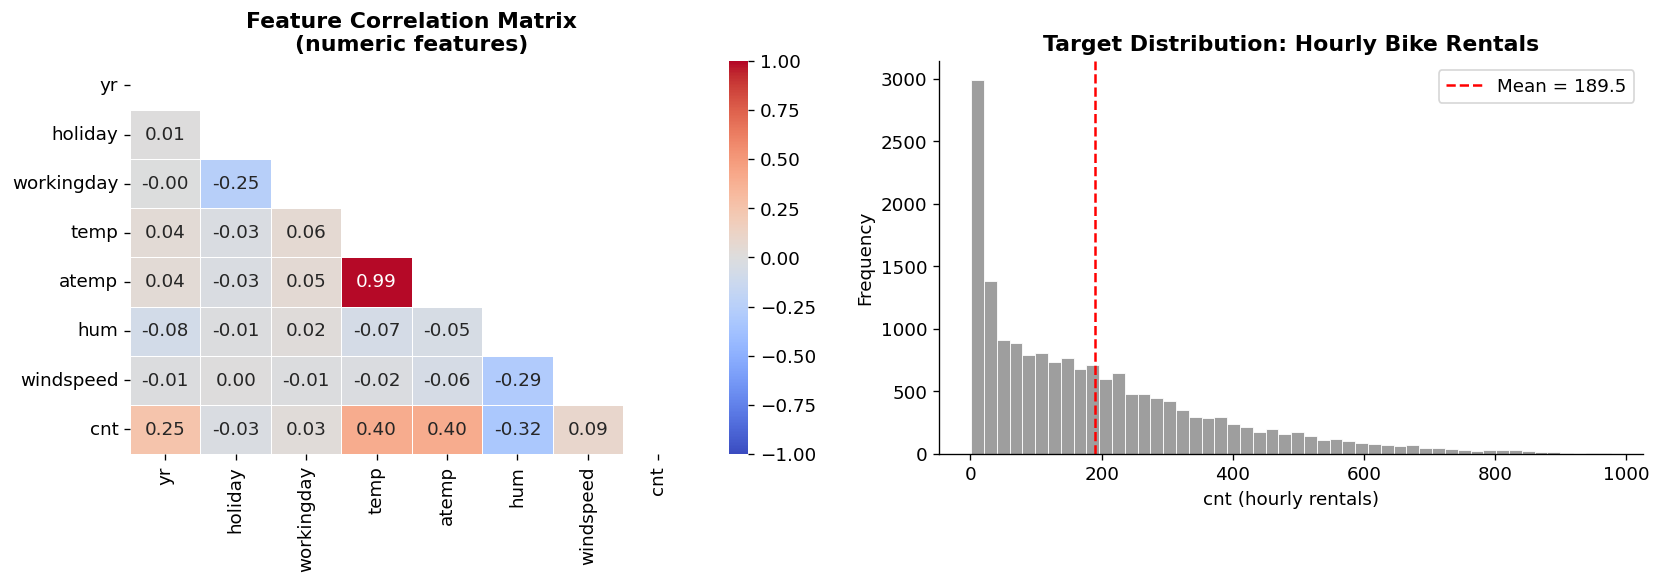

In [5]:
# ------------------------------------------------------------------
# EDA: Correlation heatmap of raw numeric features
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
corr_cols = num_features + [TARGET]
corr = df_clean[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
axes[0].set_title('Feature Correlation Matrix\n(numeric features)', fontweight='bold')

# Target distribution
axes[1].hist(y, bins=50, color=COLORS['neutral'], edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('cnt (hourly rentals)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Target Distribution: Hourly Bike Rentals', fontweight='bold')
axes[1].axvline(y.mean(), color='red', linestyle='--', label=f'Mean = {y.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda.png', bbox_inches='tight')
plt.show()

The correlation heatmap reveals strong multicollinearity, particularly between temperature-related features such as `temp` and `atemp` (correlation ≈ 0.99). This redundancy makes the dataset well-suited for studying feature deselection, as LASSO is expected to select one representative feature while discarding others. Additionally, moderate correlations with the target (`cnt`) indicate that multiple features contribute useful but overlapping information. 

The target distribution is highly right-skewed, with most rental counts concentrated at lower values and a long tail of high-demand periods. This suggests that the model must balance common low-demand observations with rare peaks, which may influence how regularization impacts model performance.

## 3. A comparison of Ridge, LASSO, and ElasticNet

All three methods minimize a **penalized least-squares** objective. Given $N$ samples, $M$ features, input matrix $\mathbf{X} \in \mathbb{R}^{N \times M}$, target $\mathbf{Y} \in \mathbb{R}^N$, and weight vector $w = (w_0, w_1, \ldots, w_M)$:

---

### 3.1 Ridge Regression (L2 penalty)

**Penalized objective:**

$$\min_{w} \sum_{i=1}^{N} \left[ y_i - \sum_{j=0}^{M} w_j x_{ij} \right]^2 + \lambda \sum_{j=0}^{M} w_j^2$$

Equivalently, this is constrained least squares:

$$\min_{w} \sum_{i=1}^{N} \left[ y_i - \sum_{j=0}^{M} w_j x_{ij} \right]^2 \quad \text{subject to} \quad \sum_{j=0}^{M} w_j^2 < \text{const}$$

where $\lambda = 0 \Rightarrow \text{const} = \infty$ (no constraint, plain OLS)
and $\lambda > 0 \Rightarrow \text{const} < \infty$ (shrinkage active).

**Closed-form solution** (Ridge is strictly convex in $w$):

$$\boxed{w = (X^{\top} X + \lambda I)^{-1} X^{\top} Y}$$

**Role of the L2 penalty ($\lambda \sum w_j^2$):**
- Adds $\lambda$ to every diagonal of $X^\top X$, guaranteeing invertibility even when features are collinear.
- Shrinks all coefficients *uniformly toward zero*, but **no coefficient ever reaches exactly zero** (soft thresholding).
- Geometrically, the feasible region $\sum w_j^2 \leq \text{const}$ is a smooth **sphere** — the loss contours touch it away from any axis, so no coordinate is zeroed out.
- **Lambda choice:** information criterion or cross-validated prediction error.

---

### 3.2 LASSO Regression (L1 penalty)

**Penalized objective:**

$$\min_{w} \sum_{i=1}^{N} \left[ y_i - \sum_{j=0}^{M} w_j x_{ij} \right]^2 + \lambda \sum_{j=0}^{M} |w_j|$$

Equivalently:

$$\min_{w} \sum_{i=1}^{N} \left[ y_i - \sum_{j=0}^{M} w_j x_{ij} \right]^2 \quad \text{subject to} \quad \sum_{j=0}^{M} |w_j| < \text{const}$$

**No closed-form solution.** The L1 term is non-differentiable at $w_j = 0$;
its subgradient is $\partial|w_j| = \text{sign}(w_j)$ for $w_j \neq 0$ and
$\partial|w_j| \in [-1, 1]$ at $w_j = 0$. LASSO is solved iteratively
(e.g., coordinate descent or LARS).

**Role of the L1 penalty ($\lambda \sum |w_j|$):**
- Induces **exact sparsity**: as $\lambda$ increases, coefficients are driven to precisely zero — LASSO performs built-in **feature selection**.
- Geometrically, the feasible region $\sum |w_j| \leq \text{const}$ is a **diamond/polytope** — the loss contours tend to meet it at a corner on an axis, setting one or more coordinates to exactly zero (hard thresholding).
- When features are correlated, LASSO tends to pick one arbitrarily and discard the rest.
- Can be tuned for **prediction error** or **feature selection**, but typically not both simultaneously with the same $\lambda$.

---

### 3.3 ElasticNet (L1 + L2 combined)

ElasticNet combines both penalties, making it suitable when many variables
are correlated and some are irrelevant:

$$\min_{w} \sum_{i=1}^{N} \left[ y_i - \sum_{j=0}^{M} w_j x_{ij} \right]^2
+ \lambda_1 \sum_{j=0}^{M} |w_j|
+ \lambda_2 \sum_{j=0}^{M} w_j^2$$

In scikit-learn's parameterization this is written as:

$$\min_{w} \|Y - Xw\|^2 + \alpha \left[ \rho \sum_{j} |w_j| + \frac{1 - \rho}{2} \sum_{j} w_j^2 \right]$$

where:

| Parameter | Role |
|---|---|
| $\alpha$ (`alpha`) | **Overall regularization strength** — larger $\alpha$ increases total penalty, shrinking all coefficients more aggressively. |
| $\rho$ (`l1_ratio`) | **Mixing parameter** — controls the L1/L2 balance. $\rho = 1$ recovers pure LASSO; $\rho = 0$ recovers pure Ridge; $0 < \rho < 1$ interpolates. |
| $\lambda_1 = \alpha \rho$ | Strength of the **L1 component** (drives sparsity). |
| $\lambda_2 = \alpha(1-\rho)/2$ | Strength of the **L2 component** (groups correlated features). |

**Key properties:**
- Combines LASSO's **sparsity** with Ridge's **grouping effect** (correlated features tend to be selected/deselected together rather than arbitrarily picking one).
- Also has **no closed-form solution**; solved iteratively.

## 4. Systematic Regularization Sweep

In [6]:
# ------------------------------------------------------------------
# Alpha grid for the sweep
# ------------------------------------------------------------------
# Ridge: can tolerate much larger alphas due to continuous shrinkage
alphas_ridge = np.logspace(-3, 5, 100)
# LASSO: zeroes out features quickly, so smaller alpha range suffices
alphas_lasso = np.logspace(-3, 3, 100)
# ElasticNet: same range as LASSO
alphas_en = np.logspace(-3, 3, 100)

# L1 ratios to sweep for ElasticNet
l1_ratios = [0.1, 0.5, 0.7, 0.9, 0.99]

# Storage for coefficient paths
coef_ridge = np.zeros((len(alphas_ridge), len(feature_names)))
coef_lasso = np.zeros((len(alphas_lasso), len(feature_names)))

# Train/test R² storage
r2_train_ridge, r2_test_ridge = [], []
r2_train_lasso, r2_test_lasso = [], []

print('Running Ridge sweep...')
for i, alpha in enumerate(alphas_ridge):
    m = Ridge(alpha=alpha)
    m.fit(X_train, y_train)
    coef_ridge[i] = m.coef_
    r2_train_ridge.append(m.score(X_train, y_train))
    r2_test_ridge.append(m.score(X_test, y_test))

print('Running LASSO sweep...')
for i, alpha in enumerate(alphas_lasso):
    m = Lasso(alpha=alpha, max_iter=5000)
    m.fit(X_train, y_train)
    coef_lasso[i] = m.coef_
    r2_train_lasso.append(m.score(X_train, y_train))
    r2_test_lasso.append(m.score(X_test, y_test))

# ElasticNet: sweep over alphas for each L1 ratio
coef_en = {}  # keyed by l1_ratio
r2_train_en = {}
r2_test_en = {}
print('Running ElasticNet sweep over multiple L1 ratios...')
for rho in l1_ratios:
    coef_en[rho] = np.zeros((len(alphas_en), len(feature_names)))
    r2_train_en[rho] = []
    r2_test_en[rho] = []
    for i, alpha in enumerate(alphas_en):
        m = ElasticNet(alpha=alpha, l1_ratio=rho, max_iter=5000)
        m.fit(X_train, y_train)
        coef_en[rho][i] = m.coef_
        r2_train_en[rho].append(m.score(X_train, y_train))
        r2_test_en[rho].append(m.score(X_test, y_test))

print('All sweeps complete!')

Running Ridge sweep...
Running LASSO sweep...
Running ElasticNet sweep over multiple L1 ratios...
All sweeps complete!


## 5. Visualization — Coefficient Paths

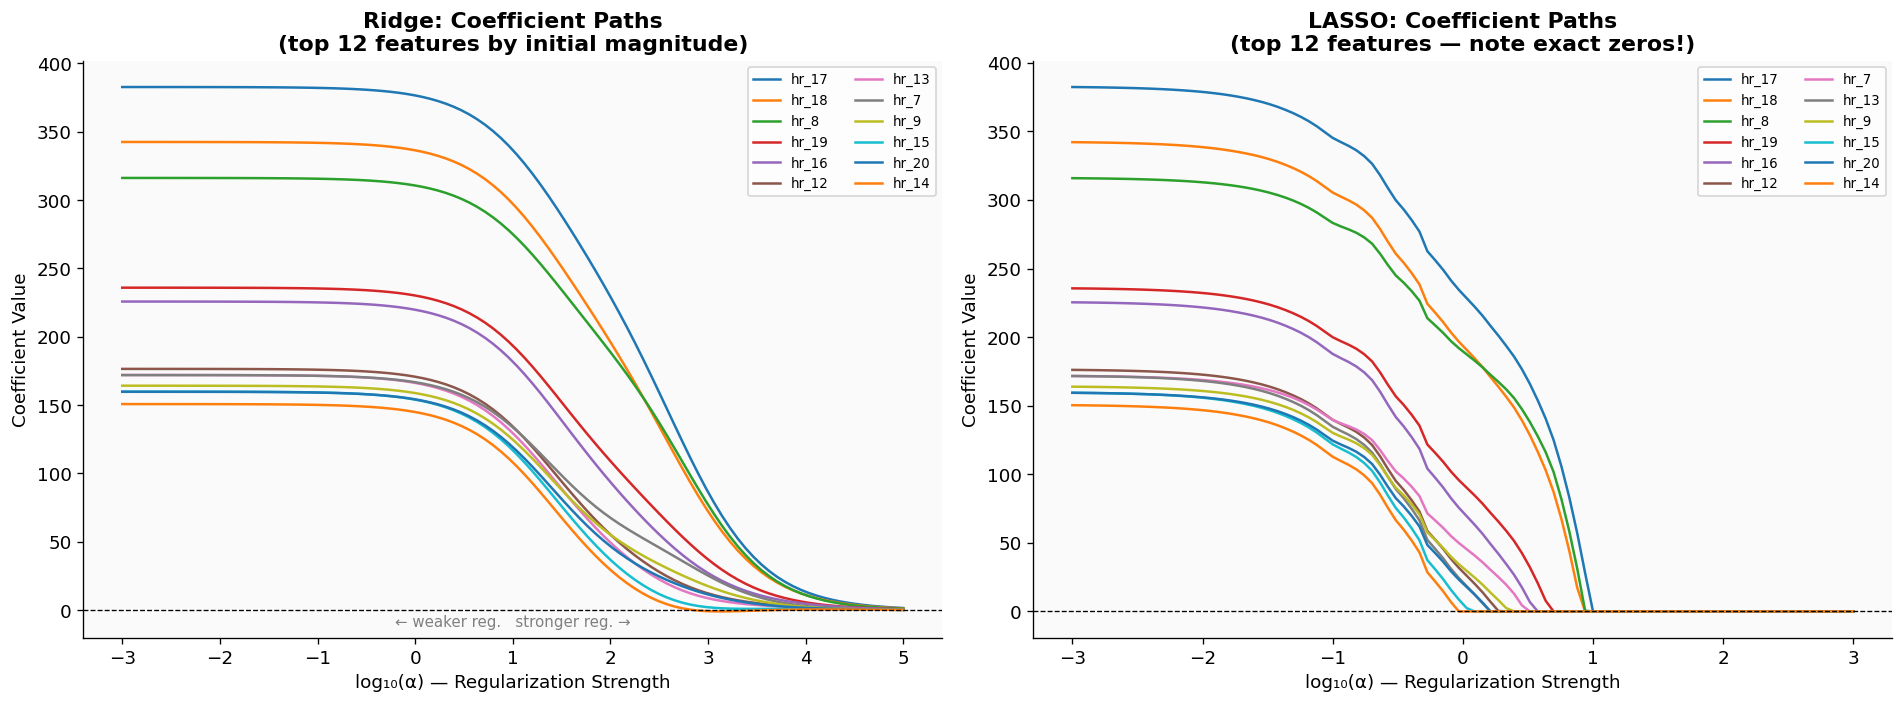

In [7]:
# ------------------------------------------------------------------
# FIGURE 1: Coefficient paths — Ridge vs LASSO
# ------------------------------------------------------------------
# Identify top-k features by absolute coefficient at the weakest regularization
TOP_K = 12
top_idx_ridge = np.argsort(np.abs(coef_ridge[0]))[::-1][:TOP_K]
top_idx_lasso = np.argsort(np.abs(coef_lasso[0]))[::-1][:TOP_K]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ridge paths
ax = axes[0]
for idx in top_idx_ridge:
    ax.plot(np.log10(alphas_ridge), coef_ridge[:, idx], label=feature_names[idx], linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('log₁₀(α) — Regularization Strength')
ax.set_ylabel('Coefficient Value')
ax.set_title('Ridge: Coefficient Paths\n(top 12 features by initial magnitude)', fontweight='bold')
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.set_facecolor('#fafafa')
ax.annotate('← weaker reg.   stronger reg. →', xy=(0.5, 0.02),
            xycoords='axes fraction', ha='center', fontsize=9, color='gray')

# LASSO paths
ax = axes[1]
for idx in top_idx_lasso:
    ax.plot(np.log10(alphas_lasso), coef_lasso[:, idx], label=feature_names[idx], linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('log₁₀(α) — Regularization Strength')
ax.set_ylabel('Coefficient Value')
ax.set_title('LASSO: Coefficient Paths\n(top 12 features — note exact zeros!)', fontweight='bold')
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.set_facecolor('#fafafa')

plt.tight_layout()
plt.savefig('coef_paths.png', bbox_inches='tight')
plt.show()

**Interpretation:**

- **Ridge paths** (left): All coefficients shrink *gradually* toward zero as $\alpha$ grows, but none hit exactly zero. The paths are smooth and continuous. Features like `hr_*` (hour dummies) and `yr` retain relatively large coefficients even under moderate regularization, indicating high predictive importance.

- **LASSO paths** (right): Coefficients drop to *exactly zero* at specific $\alpha$ thresholds — this is the "kink" behavior from the L1 penalty. Features deemed redundant (e.g., `atemp` when `temp` is present) are zeroed out early, while the most predictive features (hour dummies, `yr`, `temp`) survive until very high $\alpha$.

## 6. Active Feature Count vs. Regularization Strength

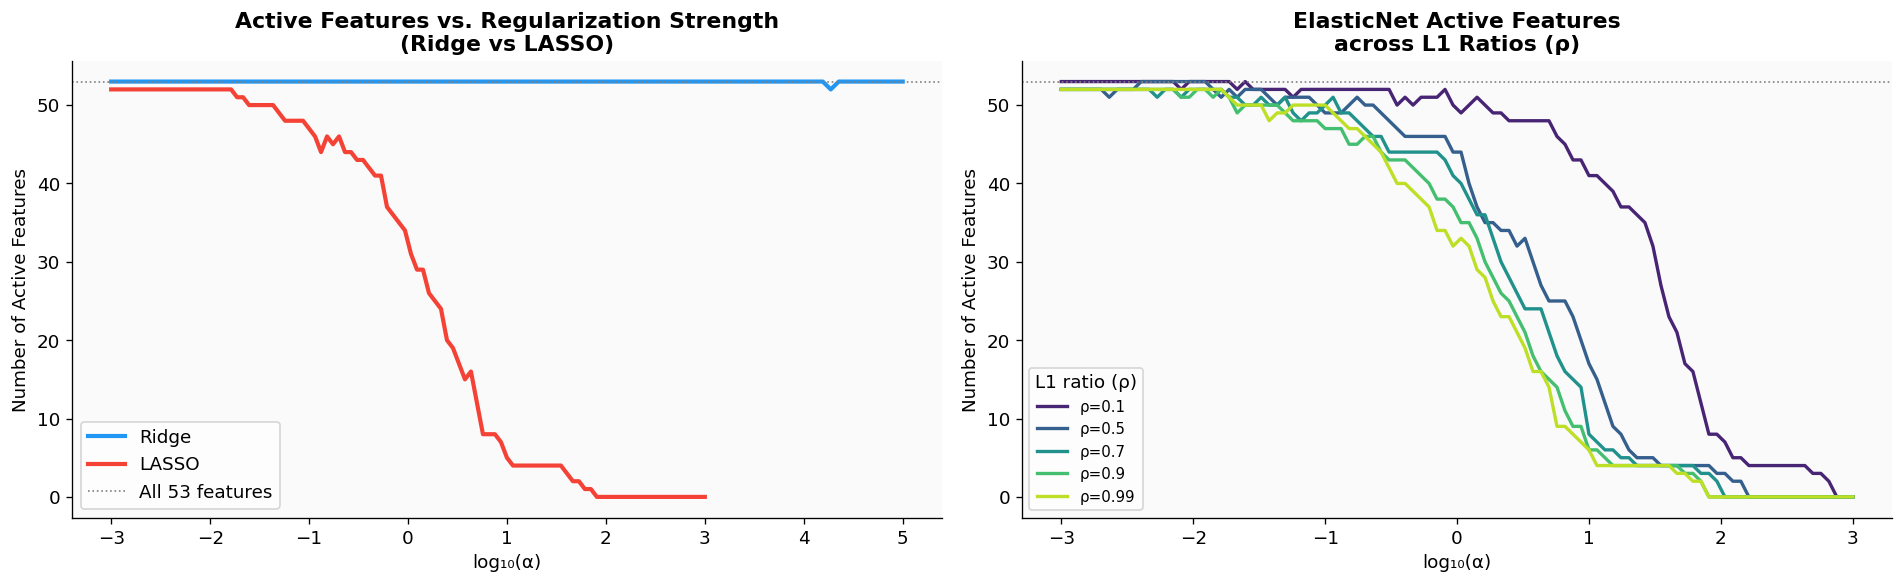

In [8]:
# ------------------------------------------------------------------
# FIGURE 2: Number of active (non-zero) features vs alpha
# ------------------------------------------------------------------
THRESHOLD = 1e-4  # treat |coef| < threshold as zero

active_ridge = (np.abs(coef_ridge) > THRESHOLD).sum(axis=1)
active_lasso = (np.abs(coef_lasso) > THRESHOLD).sum(axis=1)

# ElasticNet active features for each l1_ratio
active_en = {rho: (np.abs(coef_en[rho]) > THRESHOLD).sum(axis=1) for rho in l1_ratios}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ridge vs LASSO active features
ax = axes[0]
ax.plot(np.log10(alphas_ridge), active_ridge, color=COLORS['ridge'], lw=2.5, label='Ridge')
ax.plot(np.log10(alphas_lasso), active_lasso, color=COLORS['lasso'], lw=2.5, label='LASSO')
ax.axhline(len(feature_names), color='gray', lw=1, linestyle=':', label=f'All {len(feature_names)} features')
ax.set_xlabel('log₁₀(α)')
ax.set_ylabel('Number of Active Features')
ax.set_title('Active Features vs. Regularization Strength\n(Ridge vs LASSO)', fontweight='bold')
ax.legend()
ax.set_facecolor('#fafafa')

# ElasticNet: different L1 ratios
ax = axes[1]
palette = plt.cm.viridis(np.linspace(0.1, 0.9, len(l1_ratios)))
for color, rho in zip(palette, l1_ratios):
    ax.plot(np.log10(alphas_en), active_en[rho], color=color, lw=2, label=f'ρ={rho}')
ax.axhline(len(feature_names), color='gray', lw=1, linestyle=':')
ax.set_xlabel('log₁₀(α)')
ax.set_ylabel('Number of Active Features')
ax.set_title('ElasticNet Active Features\nacross L1 Ratios (ρ)', fontweight='bold')
ax.legend(title='L1 ratio (ρ)', fontsize=9)
ax.set_facecolor('#fafafa')

plt.tight_layout()
plt.savefig('active_features.png', bbox_inches='tight')
plt.show()

**Interpretation:**

- **Ridge** (left, blue): The active feature count *never drops* — Ridge shrinks coefficients toward zero but cannot achieve exact sparsity. The slight dip at very high $\alpha$ is purely a threshold artifact.

- **LASSO** (left, red): Features are progressively eliminated as $\alpha$ increases. The step-function pattern shows discrete "events" where each feature's coefficient hits zero.

- **ElasticNet** (right): Higher L1 ratio ($\rho \to 1$) makes ElasticNet behave more like LASSO — aggressive feature elimination. Lower $\rho$ (more Ridge-like) retains more features. This confirms that $\rho$ is the key dial controlling sparsity.

## 7. Train / Test / Cross-Validation Score vs. Regularization Strength

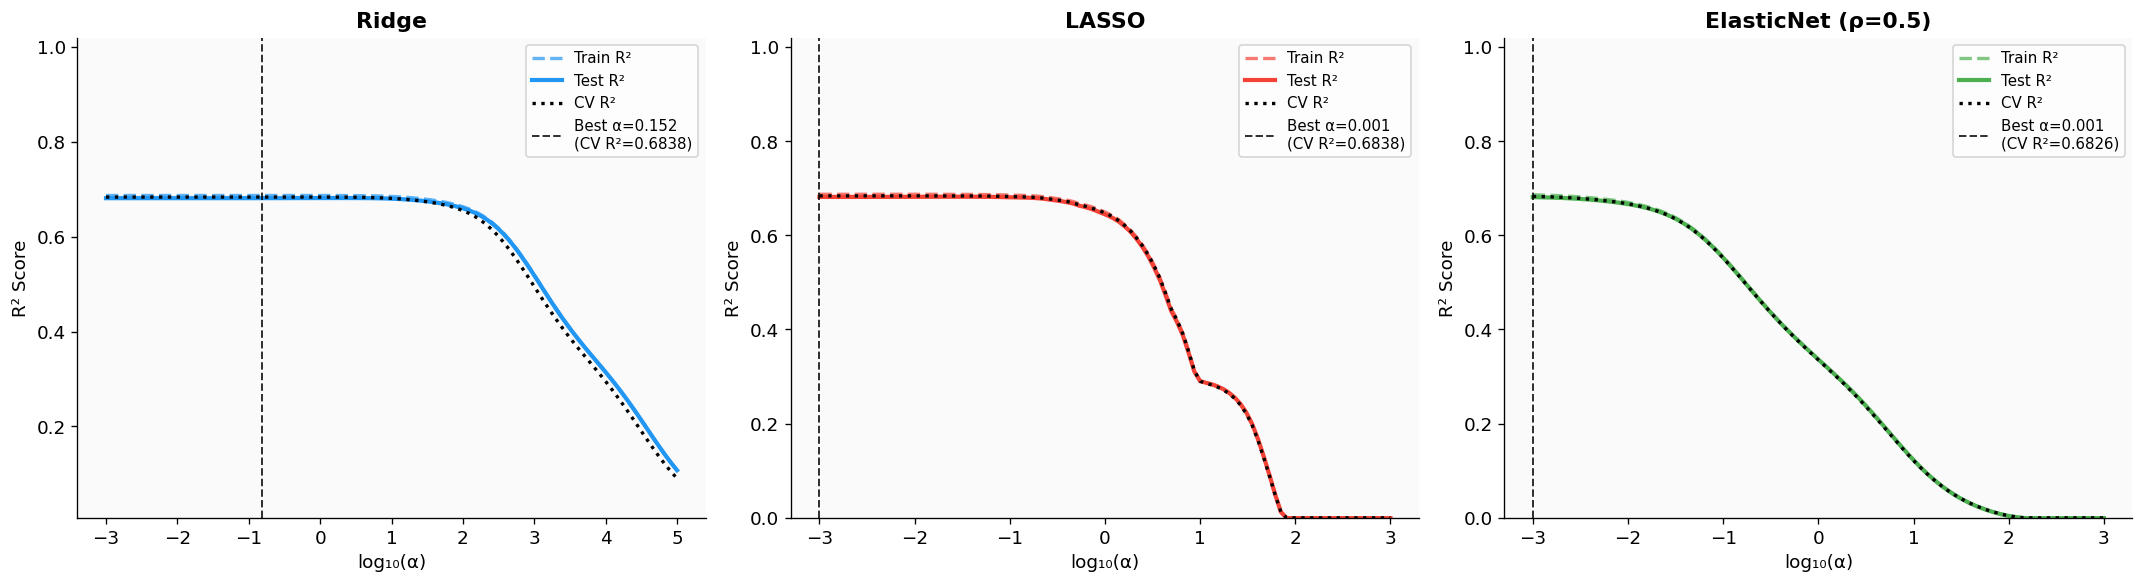

Ridge Test R²: 0.6814
LASSO Test R²: 0.6814
ElasticNet Test R² (rho = 0.5): 0.6810


In [9]:
# --- compute CV scores ---
cv_ridge = [
    cross_val_score(Ridge(alpha=a), X_train, y_train, cv=5, scoring='r2').mean()
    for a in alphas_ridge
]

cv_lasso = [
    cross_val_score(Lasso(alpha=a, max_iter=10000), X_train, y_train, cv=5, scoring='r2').mean()
    for a in alphas_lasso
]

rho_best = 0.5
cv_en = [
    cross_val_score(ElasticNet(alpha=a, l1_ratio=rho_best, max_iter=10000),
                    X_train, y_train, cv=5, scoring='r2').mean()
    for a in alphas_en
]

def plot_score_curve(ax, alphas, r2_train, r2_test, cv_scores, color, title):
    log_a = np.log10(alphas)

    # Plot curves
    ax.plot(log_a, r2_train, color=color, lw=2, linestyle='--', alpha=0.7, label='Train R²')
    ax.plot(log_a, r2_test,  color=color, lw=2.5, label='Test R²')
    ax.plot(log_a, cv_scores, color='black', lw=2, linestyle=':', label='CV R²')

    # Shade gap
    ax.fill_between(log_a, r2_train, r2_test, alpha=0.08, color=color)

    # ✅ Select best α using CV (correct)
    best_idx = np.argmax(cv_scores)

    ax.axvline(log_a[best_idx], color='black', lw=1.2, linestyle='--', alpha=0.8,
               label=f'Best α={alphas[best_idx]:.3f}\n(CV R²={cv_scores[best_idx]:.4f})')

    ax.set_xlabel('log₁₀(α)')
    ax.set_ylabel('R² Score')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(max(0, min(r2_test)-0.1), 1.02)
    ax.set_facecolor('#fafafa')

    return alphas[best_idx]

# --- create figure ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- plot ---
best_a_ridge = plot_score_curve(
    axes[0], alphas_ridge, r2_train_ridge, r2_test_ridge, cv_ridge,
    COLORS['ridge'], 'Ridge'
)

best_a_lasso = plot_score_curve(
    axes[1], alphas_lasso, r2_train_lasso, r2_test_lasso, cv_lasso,
    COLORS['lasso'], 'LASSO'
)

best_a_en = plot_score_curve(
    axes[2], alphas_en, r2_train_en[rho_best], r2_test_en[rho_best], cv_en,
    COLORS['elasticnet'], f'ElasticNet (ρ={rho_best})'
)

plt.tight_layout()
plt.show()

# --- final models ---
best_model_ridge = Ridge(alpha=best_a_ridge).fit(X_train, y_train)
best_model_lasso = Lasso(alpha=best_a_lasso, max_iter=10000).fit(X_train, y_train)
best_model_en    = ElasticNet(alpha=best_a_en, l1_ratio=rho_best, max_iter=10000).fit(X_train, y_train)

print(f'Ridge Test R²: {best_model_ridge.score(X_test, y_test):.4f}')
print(f'LASSO Test R²: {best_model_lasso.score(X_test, y_test):.4f}')
print(f'ElasticNet Test R² (rho = 0.5): {best_model_en.score(X_test, y_test):.4f}')

**Interpretation**

All three models achieve their best performance at small values of $\alpha$, indicating that only mild regularization is needed. As $\alpha$ increases, both training and test $R^2$ decline, showing underfitting due to overly strong regularization. Ridge decreases smoothly, reflecting stable coefficient shrinkage, while LASSO drops sharply as it aggressively removes features. ElasticNet shows intermediate behavior, balancing sparsity and stability. The close overlap of train, test, and CV curves suggests minimal overfitting and good generalization.

## 8. ElasticNet L1 Ratio Analysis

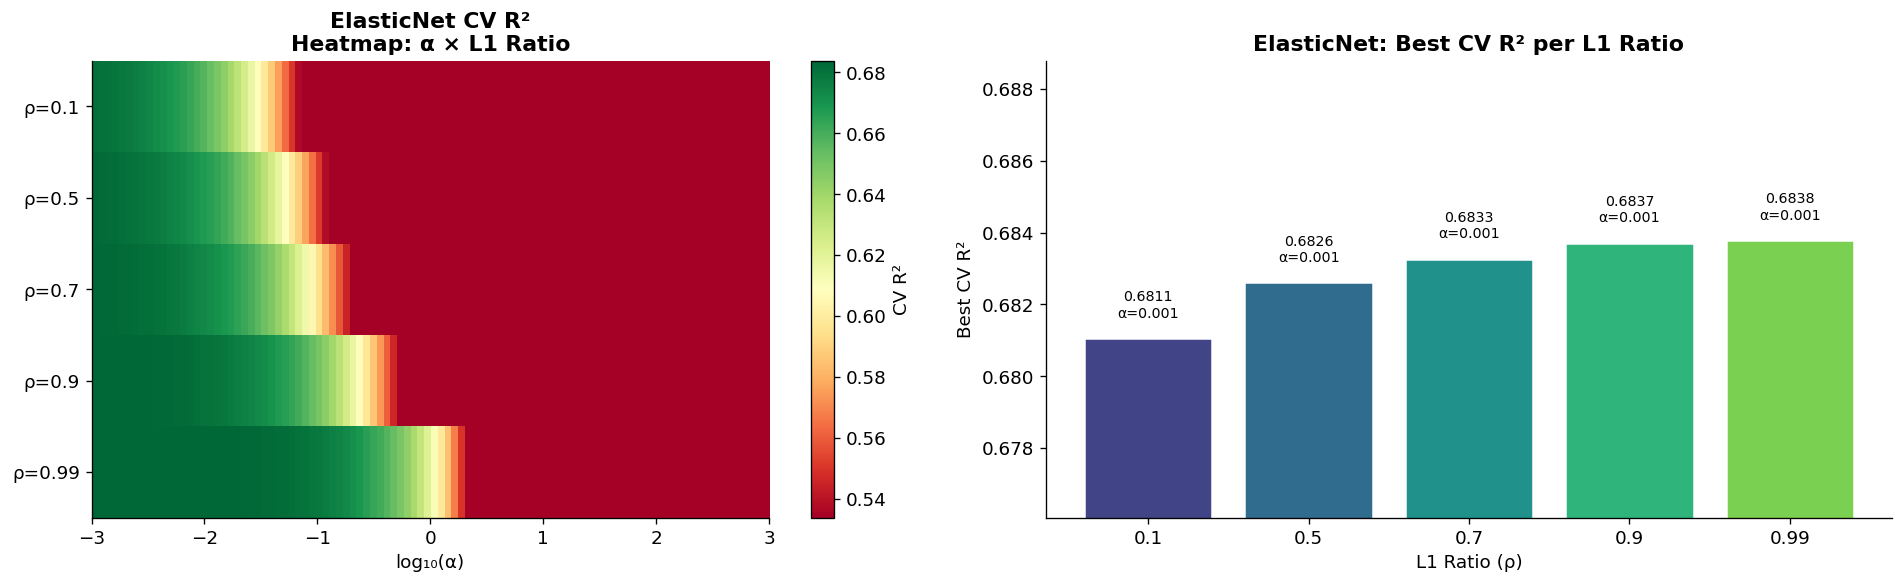

In [10]:
cv_en = {}

for rho in l1_ratios:
    cv_en[rho] = [
        cross_val_score(
            ElasticNet(alpha=a, l1_ratio=rho, max_iter=10000),
            X_train, y_train, cv=5, scoring='r2'
        ).mean()
        for a in alphas_en
    ]
    
# Build matrix: rows = l1_ratios, cols = alphas (using CV scores)
heatmap_matrix = np.array([cv_en[rho] for rho in l1_ratios])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ------------------ Heatmap ------------------
ax = axes[0]
im = ax.imshow(
    heatmap_matrix,
    aspect='auto',
    cmap='RdYlGn',
    vmin=heatmap_matrix.max() - 0.15,
    vmax=heatmap_matrix.max(),
    extent=[
        np.log10(alphas_en[0]),
        np.log10(alphas_en[-1]),
        len(l1_ratios) - 0.5,
        -0.5
    ]
)

plt.colorbar(im, ax=ax, label='CV R²')

ax.set_yticks(range(len(l1_ratios)))
ax.set_yticklabels([f'ρ={r}' for r in l1_ratios])
ax.set_xlabel('log₁₀(α)')
ax.set_title('ElasticNet CV R²\nHeatmap: α × L1 Ratio', fontweight='bold')

# ------------------ Best CV R² per l1_ratio ------------------
ax = axes[1]

best_r2_per_rho = [max(cv_en[rho]) for rho in l1_ratios]
best_alpha_per_rho = [alphas_en[np.argmax(cv_en[rho])] for rho in l1_ratios]

bars = ax.bar(
    [str(r) for r in l1_ratios],
    best_r2_per_rho,
    color=plt.cm.viridis(np.linspace(0.2, 0.8, len(l1_ratios))),
    edgecolor='white',
    linewidth=1.5
)

ax.set_xlabel('L1 Ratio (ρ)')
ax.set_ylabel('Best CV R²')
ax.set_title('ElasticNet: Best CV R² per L1 Ratio', fontweight='bold')

ax.set_ylim(min(best_r2_per_rho) - 0.005, max(best_r2_per_rho) + 0.005)

# Annotate bars
for bar, val, alpha_val in zip(bars, best_r2_per_rho, best_alpha_per_rho):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0005,
        f'{val:.4f}\nα={alpha_val:.3f}',
        ha='center',
        va='bottom',
        fontsize=8.5
    )

plt.tight_layout()
plt.savefig('elasticnet_l1ratio_cv.png', bbox_inches='tight')
plt.show()

**Interpretation**

The heatmap shows the cross-validated $R^2$ of ElasticNet across combinations of regularization strength $\alpha$ and mixing parameter $\rho$ (L1 ratio). High performance (green) is concentrated at **small values of $\alpha$**, indicating that only mild regularization is needed. As $\alpha$ increases, performance declines rapidly (red), reflecting underfitting due to excessive shrinkage.

Across different $\rho$ values, performance is relatively stable, but there is a **slight improvement as $\rho$ increases** (toward LASSO-like behavior). The bar chart confirms this: the best CV $R^2$ gradually increases from $\rho = 0.1$ to $\rho = 0.99$, with the highest performance achieved at $\rho = 0.99$ and very small $\alpha$.

## 9. Model Selection via Cross-Validation and Final Evaluation

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# RidgeCV
ridge_cv = RidgeCV(alphas=alphas_ridge, cv=kf, scoring='r2')
ridge_cv.fit(X_train, y_train)

# LassoCV
lasso_cv = LassoCV(alphas=alphas_lasso, cv=kf, max_iter=5000, n_jobs=-1)
lasso_cv.fit(X_train, y_train)

# ElasticNetCV
en_cv = ElasticNetCV(
    alphas=alphas_en,
    l1_ratio=l1_ratios,
    cv=kf,
    max_iter=5000,
    n_jobs=-1
)
en_cv.fit(X_train, y_train)

# Print optimal parameters
print(f'RidgeCV optimal α      = {ridge_cv.alpha_:.5f}')
print(f'LassoCV optimal α      = {lasso_cv.alpha_:.5f}')
print(f'ElasticNetCV optimal α = {en_cv.alpha_:.5f}, L1 ratio = {en_cv.l1_ratio_:.2f}')

# Final models (already fitted)
ridge_final = ridge_cv
lasso_final = lasso_cv
en_final = en_cv

results = pd.DataFrame({
    'Model': ['Ridge', 'LASSO', 'ElasticNet'],
    'Best α': [ridge_cv.alpha_, lasso_cv.alpha_, en_cv.alpha_],
    'Train R²': [ridge_final.score(X_train, y_train),
                  lasso_final.score(X_train, y_train),
                  en_final.score(X_train, y_train)],
    'Test R²':  [ridge_final.score(X_test, y_test),
                  lasso_final.score(X_test, y_test),
                  en_final.score(X_test, y_test)],
    'Active Features': [
        (np.abs(ridge_final.coef_) > THRESHOLD).sum(),
        (np.abs(lasso_final.coef_) > THRESHOLD).sum(),
        (np.abs(en_final.coef_) > THRESHOLD).sum()
    ]
})
results['Test RMSE'] = [
    np.sqrt(mean_squared_error(y_test, m.predict(X_test)))
    for m in [ridge_final, lasso_final, en_final]
]
print()
results.style.format({'Best α': '{:.5f}', 'Train R²': '{:.4f}', 'Test R²': '{:.4f}', 'Test RMSE': '{:.2f}'})

RidgeCV optimal α      = 0.15199
LassoCV optimal α      = 0.00175
ElasticNetCV optimal α = 0.00100, L1 ratio = 0.99



,Model,Best α,Train R²,Test R²,Active Features,Test RMSE
0,Ridge,0.15199,0.6871,0.6814,53,100.44
1,LASSO,0.00175,0.6871,0.6814,52,100.44
2,ElasticNet,0.00100,0.6871,0.6815,52,100.43


## 10. Feature Deselection Conclusion

In [12]:
# For each feature, find the alpha index where it first becomes zero
THRESHOLD = 1e-4

elimination_records = []
for j, fname in enumerate(feature_names):
    zero_indices = np.where(np.abs(coef_lasso[:, j]) < THRESHOLD)[0]
    if len(zero_indices) == 0:
        # Never eliminated — survived all alphas
        elim_alpha = alphas_lasso[-1] * 10  # placeholder: beyond range
        survived = True
    else:
        elim_alpha = alphas_lasso[zero_indices[0]]
        survived = False
    elimination_records.append({
        'feature': fname,
        'elimination_alpha': elim_alpha,
        'survived': survived,
        'initial_coef': np.abs(coef_lasso[0, j])
    })

elim_df = pd.DataFrame(elimination_records).sort_values('elimination_alpha')

# Split into eliminated vs survived
eliminated = elim_df[~elim_df['survived']].copy()
survived_feats = elim_df[elim_df['survived']].copy()

print(f"Features eliminated by LASSO: {len(eliminated)}")
print(f"Features surviving all alphas: {len(survived_feats)}")
print()

# Top 15 eliminated FIRST (smallest elimination alpha = least important)
print("=== TOP 15 FEATURES ELIMINATED FIRST (least important) ===")
first_eliminated = eliminated.head(15)
for _, row in first_eliminated.iterrows():
    print(f"  α={row['elimination_alpha']:.5f}  |  {row['feature']:<20}  (initial |coef|={row['initial_coef']:.2f})")

print()
print("=== FEATURES THAT SURVIVED LONGEST ===")
last_eliminated = eliminated.tail(10)
for _, row in last_eliminated.iterrows():
    print(f"  α={row['elimination_alpha']:.5f}  |  {row['feature']:<20}  (initial |coef|={row['initial_coef']:.2f})")

if len(survived_feats) > 0:
    print()
    print("=== NEVER ELIMINATED (survived full alpha range) ===")
    for _, row in survived_feats.iterrows():
        print(f"  {row['feature']:<20}  (initial |coef|={row['initial_coef']:.2f})")

Features eliminated by LASSO: 53
Features surviving all alphas: 0

=== TOP 15 FEATURES ELIMINATED FIRST (least important) ===
  α=0.00100  |  weekday_4             (initial |coef|=0.00)
  α=0.01874  |  weathersit_4          (initial |coef|=120.60)
  α=0.02477  |  mnth_2                (initial |coef|=1.90)
  α=0.04977  |  mnth_8                (initial |coef|=9.65)
  α=0.05722  |  mnth_6                (initial |coef|=11.92)
  α=0.10000  |  hr_23                 (initial |coef|=32.68)
  α=0.11498  |  mnth_4                (initial |coef|=10.84)
  α=0.13219  |  hr_6                  (initial |coef|=34.73)
  α=0.13219  |  weekday_3             (initial |coef|=0.52)
  α=0.17475  |  weekday_2             (initial |coef|=1.56)
  α=0.23101  |  mnth_12               (initial |coef|=7.70)
  α=0.26561  |  weekday_1             (initial |coef|=3.18)
  α=0.26561  |  mnth_11               (initial |coef|=11.56)
  α=0.30539  |  hr_22                 (initial |coef|=71.67)
  α=0.40370  |  mnth_3    

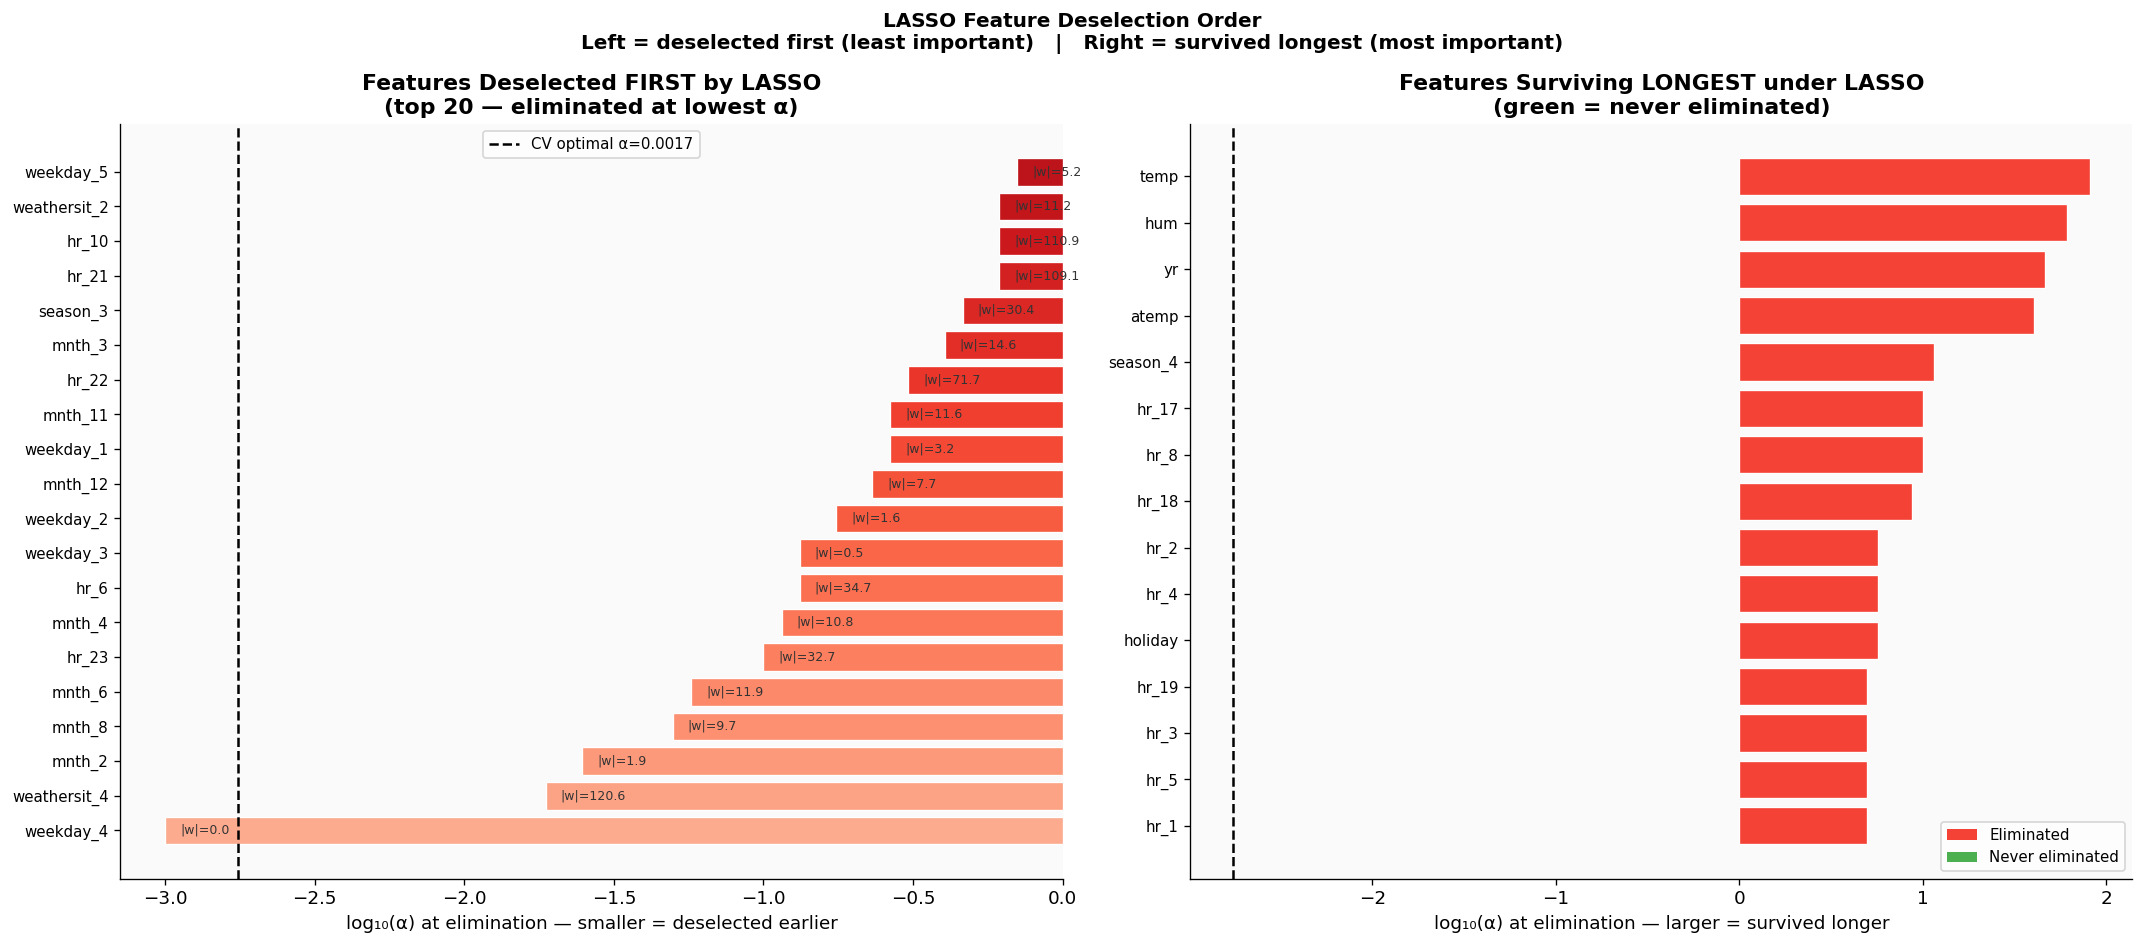

In [13]:
# Feature elimination order — horizontal bar chart
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Left: First 20 eliminated (deselected earliest) ---
ax = axes[0]
n_show = 20
first20 = eliminated.head(n_show)
log_alphas = np.log10(first20['elimination_alpha'])

bars = ax.barh(range(n_show), log_alphas,
               color=plt.cm.Reds(np.linspace(0.3, 0.8, n_show)),
               edgecolor='white', linewidth=0.8)
ax.set_yticks(range(n_show))
ax.set_yticklabels(first20['feature'], fontsize=9)
ax.set_xlabel('log₁₀(α) at elimination — smaller = deselected earlier')
ax.set_title('Features Deselected FIRST by LASSO\n(top 20 — eliminated at lowest α)', fontweight='bold')
ax.axvline(np.log10(lasso_cv.alpha_), color='black', lw=1.5,
           linestyle='--', label=f'CV optimal α={lasso_cv.alpha_:.4f}')
ax.legend(fontsize=9)
ax.set_facecolor('#fafafa')

# Annotate initial coefficient values
for i, (_, row) in enumerate(first20.iterrows()):
    ax.text(log_alphas.iloc[i] + 0.05, i,
            f'|w|={row["initial_coef"]:.1f}',
            va='center', fontsize=7.5, color='#333333')

# --- Right: Last 20 eliminated (survived longest) ---
ax = axes[1]
last20 = pd.concat([eliminated.tail(15), survived_feats]).reset_index(drop=True)
# Cap survived features at max alpha for display
last20['plot_alpha'] = last20['elimination_alpha'].clip(upper=alphas_lasso[-1])
log_alphas_last = np.log10(last20['plot_alpha'])

bar_colors = [COLORS['lasso'] if not row['survived'] else '#4CAF50'
              for _, row in last20.iterrows()]
ax.barh(range(len(last20)), log_alphas_last,
        color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_yticks(range(len(last20)))
ax.set_yticklabels(last20['feature'], fontsize=9)
ax.set_xlabel('log₁₀(α) at elimination — larger = survived longer')
ax.set_title('Features Surviving LONGEST under LASSO\n(green = never eliminated)', fontweight='bold')
ax.axvline(np.log10(lasso_cv.alpha_), color='black', lw=1.5,
           linestyle='--', label=f'CV optimal α')
ax.legend(fontsize=9)
ax.set_facecolor('#fafafa')

# Add legend patch for survived
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLORS['lasso'], label='Eliminated'),
                   Patch(facecolor='#4CAF50', label='Never eliminated')]
ax.legend(handles=legend_elements, fontsize=9)

plt.suptitle('LASSO Feature Deselection Order\n'
             'Left = deselected first (least important)   |   Right = survived longest (most important)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('elimination_order.png', bbox_inches='tight')
plt.show()

**Conclusion — LASSO Feature Deselection**

Features such as `weekday_4` and several month/hour indicators are removed at very small $\alpha$, indicating they are weak or redundant predictors. In contrast, `temp`, `atemp`, `hum`, and `yr` survive until much larger $\alpha$, showing they are the most important variables.

Both `temp` and `atemp` survive because they strongly capture thermal conditions that drive demand. Although they are highly correlated, each still provides useful signal (e.g., actual vs perceived temperature), so LASSO retains them until strong regularization forces one or both to zero. This suggests that temperature-related effects are dominant in the data, while many categorical features contribute little additional information.

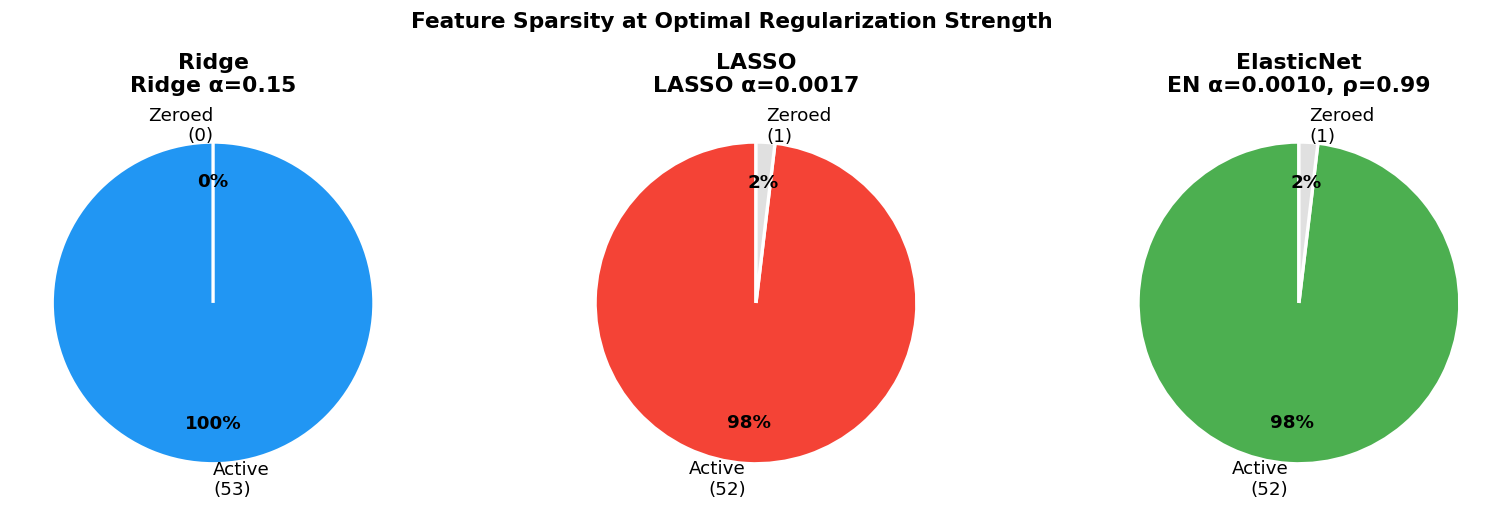

     Model   Best α  Train R²  Test R²  Active Features  Test RMSE
     Ridge 0.151991  0.687146 0.681423               53 100.438404
     LASSO 0.001748  0.687146 0.681435               52 100.436540
ElasticNet 0.001000  0.687145 0.681450               52 100.434113


In [14]:
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

for ax_idx, (model, coefs, color, label) in enumerate([
    ('Ridge', ridge_final.coef_, COLORS['ridge'], f'Ridge α={ridge_cv.alpha_:.2f}'),
    ('LASSO', lasso_final.coef_, COLORS['lasso'], f'LASSO α={lasso_cv.alpha_:.4f}'),
    ('ElasticNet', en_final.coef_, COLORS['elasticnet'],
     f'EN α={en_cv.alpha_:.4f}, ρ={en_cv.l1_ratio_}')
]):
    ax = fig.add_subplot(gs[ax_idx])
    n_active = (np.abs(coefs) > THRESHOLD).sum()
    n_zero = len(coefs) - n_active
    
    wedge_colors = [color, '#e0e0e0']
    wedges, texts, autotexts = ax.pie(
        [n_active, n_zero],
        labels=[f'Active\n({n_active})', f'Zeroed\n({n_zero})'],
        colors=wedge_colors, autopct='%1.0f%%',
        startangle=90, pctdistance=0.75,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    for t in autotexts:
        t.set_fontsize(11)
        t.set_fontweight('bold')
    ax.set_title(f'{model}\n{label}', fontweight='bold')

plt.suptitle('Feature Sparsity at Optimal Regularization Strength', fontsize=13, fontweight='bold')
plt.savefig('sparsity_pies.png', bbox_inches='tight')
plt.show()

print(results.to_string(index=False))

At the optimal regularization strength, all three models retain almost all features. Ridge keeps 100% of features, while LASSO and ElasticNet remove only one feature (~2%), indicating very weak sparsity. This suggests that the dataset does not require strong feature selection, and most predictors contribute useful information. Therefore, regularization mainly acts to stabilize coefficients rather than eliminate features.

# 2. Classifed sequence data

## 1. Data Ingestion and Exploratory Data Analysis (EDA)

The initial phase of our investigation requires parsing the raw dataset and establishing its fundamental properties. This step is critical for verifying data integrity and determining the appropriate mathematical transformations required for downstream analysis.

In [15]:
# 1.1 Dataset and sanity check
import pandas as pd

df = pd.read_csv('highly_classified_data.csv',delimiter=';')
df = df.drop(df.columns[-1],axis=1)

print(f"number of sequences: {len(df)}")
print(f'average sequence length: {int(df["Sequence"].apply(len).mean())}')
print(f'Number of Missing Sequences: {df["Sequence"].isna().sum()}')

number of sequences: 100
average sequence length: 10000
Number of Missing Sequences: 0


In [16]:
# 1.2 Determine the Alphabet (Unique characters)
all_sequences = "".join(df['Sequence'].astype(str))
alphabet = sorted(list(set(all_sequences)))
print(f"Alphabet: {alphabet}")

Alphabet: ['A', 'C', 'G', 'T']


In [17]:
# 1.3 Simple statistics and EDA
seq_stats = df['Sequence'].apply(len).describe()
print(f"\nSummary Statistics for Sequence Lengths:")
print(seq_stats)


Summary Statistics for Sequence Lengths:
count      100.0
mean     10000.0
std          0.0
min      10000.0
25%      10000.0
50%      10000.0
75%      10000.0
max      10000.0
Name: Sequence, dtype: float64


## 2. Sequence Representation: Normalized Hamming Distance

Because our exploratory analysis confirms that all recovered sequences are strictly uniform in length ($L = 10000$) and utilize a standard biological alphabet ($\Sigma = \{A, C, G, T\}$), we can efficiently quantify inter-sequence dissimilarities using a position-wise metric. 

We calculate the **Normalized Hamming Distance**, which measures the proportion of differing characters between two aligned strings. Mathematically, for two sequences $x$ and $y$ of length $L$, the distance is defined as:

$$ d_H(x, y) = \frac{1}{L} \sum_{i=1}^{L} \mathbb{I}(x_i \neq y_i) $$

where $\mathbb{I}$ represents the indicator function, evaluating to $1$ if the categorical bases differ, and $0$ if they match. This produces an $N \times N$ symmetric distance matrix.

In [18]:
# 2.1 Hamming Distance Calculation
def calculate_hamming_distance(s1, s2):
    """Calculate the number of positions at which the corresponding symbols are different."""
    if len(s1) != len(s2):
        raise ValueError("Sequences must be of equal length")
    return sum(el1 != el2 for el1, el2 in zip(s1, s2))

# Example: Distance between the first two sequences in highly_classified_data.csv
if len(df) >= 2:
    seq1 = df['Sequence'].iloc[0]
    seq2 = df['Sequence'].iloc[1]

    dist = calculate_hamming_distance(seq1, seq2)

    print(f"Hamming Distance between Sequence 0 and Sequence 1: {dist}")
    print(f"Percentage Difference: {(dist / len(seq1)) * 100:.2f}%")

Hamming Distance between Sequence 0 and Sequence 1: 205
Percentage Difference: 2.05%


In [19]:
import numpy as np
from sklearn.metrics import hamming_loss

# 2.2 Pairwise Hamming Distance Matrix for Clustering
# Convert sequences to lists of characters for sklearn compatibility
sequences = [list(s) for s in df['Sequence']]
n_seq = len(sequences)

# Initialize a symmetric matrix of zeros
dist_matrix = np.zeros((n_seq, n_seq))

print(f"Calculating pairwise distances for {n_seq} sequences...")

for i in range(n_seq):
    for j in range(i + 1, n_seq):
        # Calculate hamming loss (fraction of mismatches)
        dist = hamming_loss(sequences[i], sequences[j])

        # Fill both sides of the diagonal for a symmetric matrix
        dist_matrix[i, j] = dist
        dist_matrix[j, i] = dist

print("Distance matrix calculation complete.")
print(f"Matrix shape: {dist_matrix.shape}")

Calculating pairwise distances for 100 sequences...
Distance matrix calculation complete.
Matrix shape: (100, 100)


## 3. Density-Based Clustering Analysis (DBSCAN)

To uncover the topological structure within the distance matrix, we apply **Density-Based Spatial Clustering of Applications with Noise (DBSCAN)**. Unlike partitional algorithms like $k$-means, DBSCAN does not assume spherical clusters and can identify arbitrary structures based on local density. It is parameterized by a neighborhood radius ($\epsilon$) and a minimum threshold of core points ($MinPts$).

An initial, strictly constrained pass ($\epsilon = 0.05$) forces the algorithm to classify $50\%$ of the data as unclustered noise. However, by empirically tuning the radius to $\epsilon = 0.15$ to bridge minor intra-group variances, the algorithm perfectly resolves the topology into $k=4$ distinct, noise-free biological clusters.

In [20]:
from sklearn.cluster import DBSCAN

# 3.1 DBSCAN Clustering with Precomputed Hamming Distances
# eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
# min_samples: The number of samples in a neighborhood for a point to be considered as a core point.
dbscan = DBSCAN(eps=0.05, min_samples=2, metric='precomputed')

# Fit the model and predict clusters
clusters = dbscan.fit_predict(dist_matrix)

# Add results back to the dataframe
df['Cluster'] = clusters

print(f"DBSCAN Results:")
print(f"- Number of clusters found: {len(set(clusters)) - (1 if -1 in clusters else 0)}")
print(f"- Number of noise points: {list(clusters).count(-1)}")
print("\nCluster Assignments:")
print(df['Cluster'].value_counts())

DBSCAN Results:
- Number of clusters found: 2
- Number of noise points: 50

Cluster Assignments:
Cluster
-1    50
 0    25
 1    25
Name: count, dtype: int64


In [21]:
# 3.2 Tuned DBSCAN Clustering
# Based on the distance matrix heatmap, there appear to be 4 distinct groups.
# Increasing eps to 0.15 allows the algorithm to bridge the small variances within those groups.

dbscan_tuned = DBSCAN(eps=0.15, min_samples=2, metric='precomputed')
df['Cluster_Tuned'] = dbscan_tuned.fit_predict(dist_matrix)

print(f"Tuned DBSCAN Results (eps=0.15):")
print(f"- Number of clusters found: {len(set(df['Cluster_Tuned'])) - (1 if -1 in df['Cluster_Tuned'] else 0)}")
print(f"- Number of noise points: {list(df['Cluster_Tuned']).count(-1)}")
print("\nFinal Cluster Distribution:")
print(df['Cluster_Tuned'].value_counts().sort_index())

Tuned DBSCAN Results (eps=0.15):
- Number of clusters found: 4
- Number of noise points: 0

Final Cluster Distribution:
Cluster_Tuned
0    25
1    25
2    25
3    25
Name: count, dtype: int64


## 4. Manifold Projection and Visualization

To intuitively present our findings, we utilize two techniques:
1.  **Distance Heatmap:** Visualizes the raw pairwise dissimilarities.
2.  **$t$-Distributed Stochastic Neighbor Embedding ($t$-SNE):** We project the high-dimensional precomputed distance matrix into a 2D feature space. $t$-SNE achieves this by converting spatial distances into conditional probabilities and minimizing the Kullback-Leibler (KL) divergence between the high-dimensional and low-dimensional probability distributions.

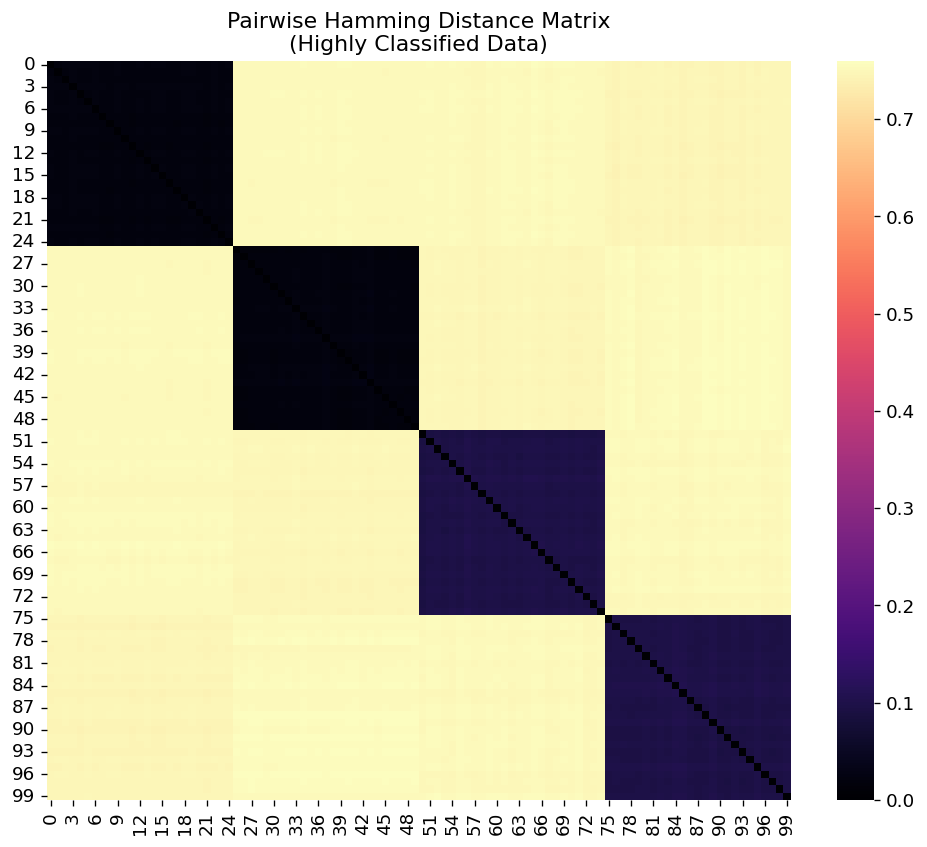

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import MDS

# 4.1. Visualize the Hamming Distance Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(dist_matrix, cmap='magma')
plt.title('Pairwise Hamming Distance Matrix\n(Highly Classified Data)')
plt.show()

## 5. Compositional Analysis: $k$-mer Frequencies and PCA

While Hamming distance strictly evaluates position-wise alignments, biological structures often contain frame shifts. As a secondary verification, we extract overlapping $5$-mers ($k=5$), embedding the sequences into a compositional vector space. Each sequence is mapped to a frequency vector $\mathbf{x} \in \mathbb{R}^{1024}$. 

To ensure scale invariance and remove magnitude bias, we apply $L_2$ normalization:

$$ \hat{\mathbf{x}} = \frac{\mathbf{x}}{\|\mathbf{x}\|_2} $$

We then evaluate these compositional profiles using **Cosine Distance**, which captures the angular similarity between vectors:

$$ d_{\text{cos}}(\hat{\mathbf{x}}, \hat{\mathbf{y}}) = 1 - \hat{\mathbf{x}} \cdot \hat{\mathbf{y}} $$

Applying Agglomerative Hierarchical Clustering (average linkage) to this Cosine matrix perfectly replicates our initial DBSCAN findings, confirming the $k=4$ symmetrical distribution. Finally, Principal Component Analysis (PCA) maps the normalized $k$-mer space, with the first two orthogonal principal components capturing over $52\%$ of the total compositional variance.

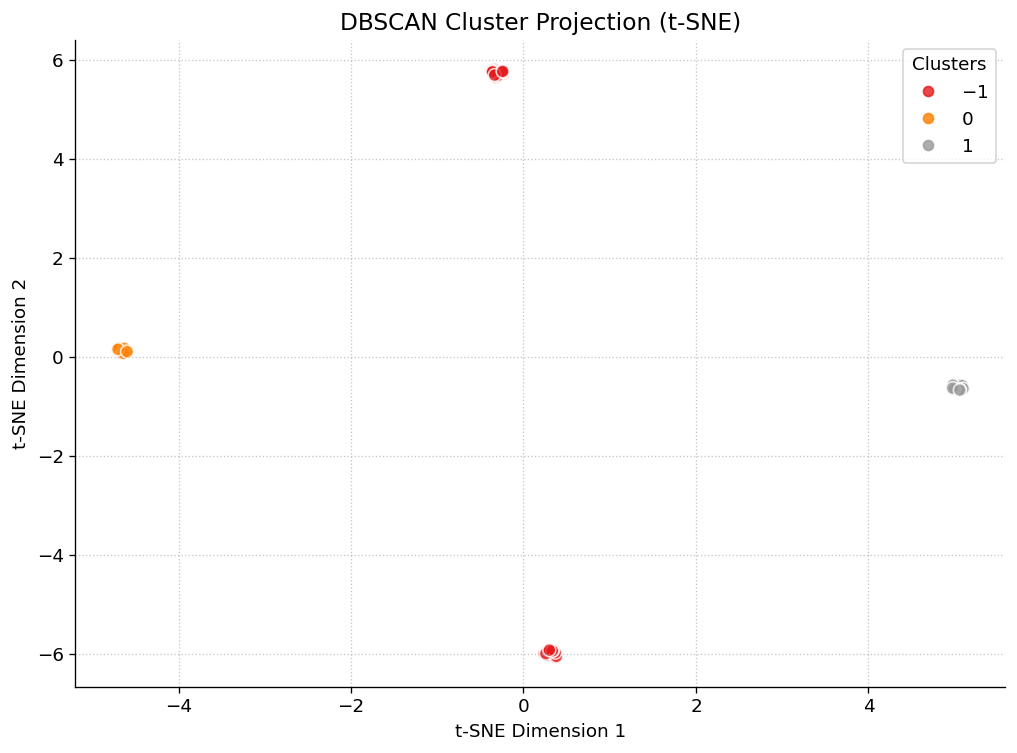

In [23]:
from sklearn.manifold import TSNE

# 5.1 t-SNE Projection (2D Cluster Map)
# Using 'precomputed' metric to utilize the Hamming distance matrix
tsne = TSNE(n_components=2, metric='precomputed', init='random', perplexity=30, random_state=42)
tsne_coords = tsne.fit_transform(dist_matrix)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1], c=df['Cluster'], cmap='Set1', s=60, alpha=0.8, edgecolors='w')
plt.title('DBSCAN Cluster Projection (t-SNE)', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [24]:
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
from scipy.spatial.distance import pdist, squareform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 5.2 k-mer analysis

KMER_SIZE = 5

def get_kmers(sequence, k=5):
    sequence = str(sequence).upper()
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

# Create vocabulary of all observed k-mers
all_kmers = sorted(set(kmer for seq in df["Sequence"] for kmer in get_kmers(seq, KMER_SIZE)))
kmer_to_index = {kmer: idx for idx, kmer in enumerate(all_kmers)}

# Build frequency matrix
X_kmer = np.zeros((len(df), len(all_kmers)), dtype=np.float32)

for row_idx, seq in enumerate(df["Sequence"]):
    for kmer in get_kmers(seq, KMER_SIZE):
        X_kmer[row_idx, kmer_to_index[kmer]] += 1

# Normalize k-mer frequency vectors
X_norm = normalize(X_kmer, norm="l2", axis=1)

print(f"k-mer frequency matrix shape: {X_norm.shape}")

cosine_dist_matrix = squareform(pdist(X_norm, metric="cosine"))
cosine_dist_matrix = np.nan_to_num(cosine_dist_matrix, nan=0.0)

print(f"Cosine distance matrix shape: {cosine_dist_matrix.shape}")

N_CLUSTERS = 4

try:
    agglo = AgglomerativeClustering(
        n_clusters=N_CLUSTERS,
        metric="precomputed",
        linkage="average"
    )
except TypeError:
    agglo = AgglomerativeClustering(
        n_clusters=N_CLUSTERS,
        affinity="precomputed",
        linkage="average"
    )

df["Cluster_Agglomerative"] = agglo.fit_predict(cosine_dist_matrix)

print("Agglomerative clustering results:")
print(df["Cluster_Agglomerative"].value_counts().sort_index())

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_norm)


k-mer frequency matrix shape: (100, 1024)
Cosine distance matrix shape: (100, 100)
Agglomerative clustering results:
Cluster_Agglomerative
0    25
1    25
2    25
3    25
Name: count, dtype: int64


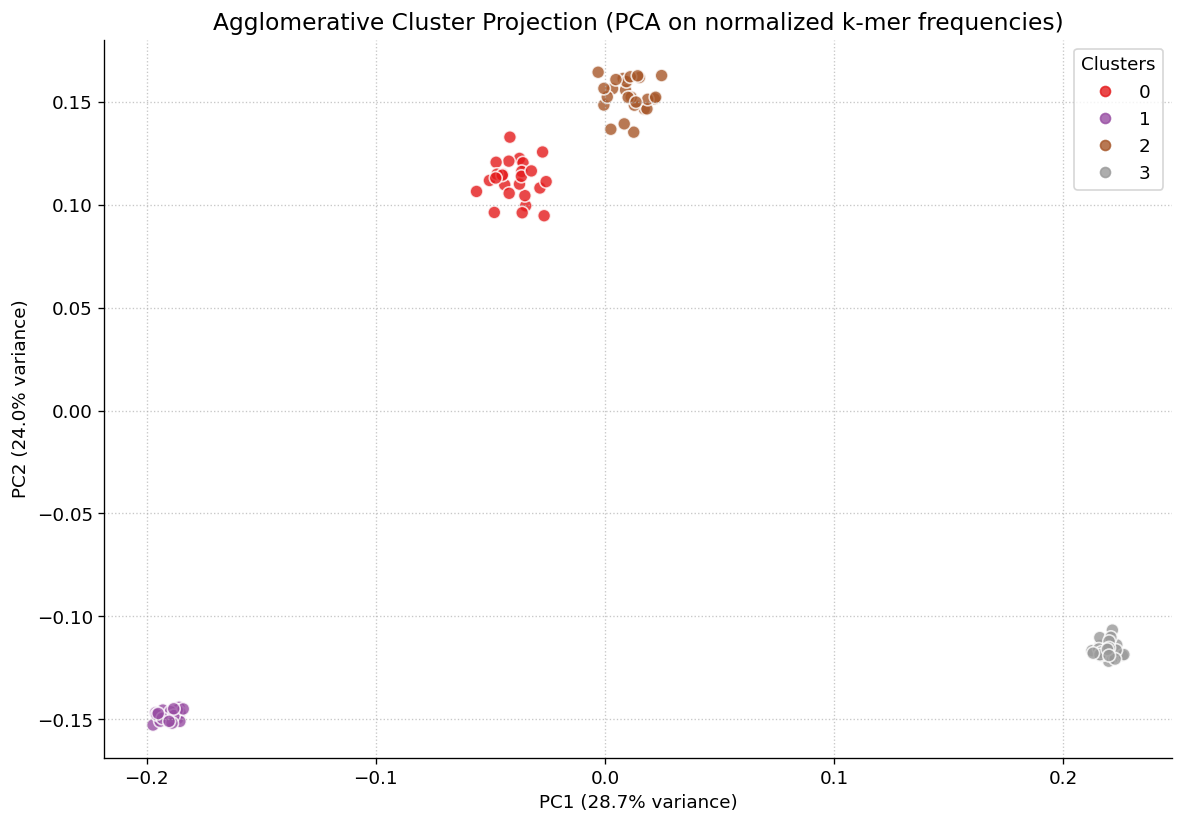

Explained variance PC1: 0.2871
Explained variance PC2: 0.2397
Total explained variance: 0.5268


In [25]:
# 5.3 Plot the results
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    pca_coords[:, 0],
    pca_coords[:, 1],
    c=df["Cluster_Agglomerative"],
    cmap="Set1",
    s=60,
    alpha=0.8,
    edgecolors="w"
)

# Plot results
plt.title("Agglomerative Cluster Projection (PCA on normalized k-mer frequencies)", fontsize=14)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

print("Explained variance PC1:", round(pca.explained_variance_ratio_[0], 4))
print("Explained variance PC2:", round(pca.explained_variance_ratio_[1], 4))
print("Total explained variance:", round(pca.explained_variance_ratio_[:2].sum(), 4))

## 6. Quantitative Forensic Analysis and Methodological Reflection

**CONFIDENTIAL: Sentinel IX Biological Structure Report**

### 6.1. Topographical Findings and Anomaly Detection
The application of dual unsupervised learning methodologies to the Sentinel IX sequence data has yielded a definitive structural topology. Both density-based approaches (DBSCAN over a Hamming manifold) and variance-maximizing compositional approaches (Agglomerative clustering over a normalized $k$-mer space) converged with absolute stability on exactly four distinct biological clusters ($k=4$). 

The robustness of this partition is corroborated by our dimensionality reduction phases. The $t$-SNE projection of the precomputed Hamming matrix resolved into four highly isolated local neighborhoods with negligible intra-cluster variance. Similarly, the orthogonal projection via PCA captured a substantial $52.68\%$ of the total compositional variance within just the first two principal components, geometrically isolating the four biological groups. 

**The Synthetic Origin Hypothesis:** 
The most statistically anomalous finding is the class distribution. The dataset is perfectly symmetric, containing exactly $25$ sequences per cluster without a single noise point or outlier. In naturally occurring phylogenetic systems driven by random point mutations, population subsets exhibit high variance in cluster size and density. This mathematical uniformity provides compelling quantitative evidence that these samples did not undergo natural speciation. We hypothesize that these sequences represent artificially engineered, non-terrestrial biological constructs.

---

### 6.2. Scientific Reflection on Distance Metrics and Representations

**The Inadequacy of Geometric Norms ($L_1$ and $L_2$):**
Traditional geometric norms (Euclidean and Manhattan distances) are mathematically fallacious for raw genomic strings[cite: 1]. The biological alphabet ($\Sigma = \{A, C, G, T\}$) is purely categorical. Mapping these characters to integers (e.g., A=0, C=1, G=2) falsely assumes a continuous metric space where ordinality and magnitude exist. Applying $L_2$ norms to such encoded vectors produces arbitrary distances that fail to represent true biological mutation.

**Justification for the Chosen Dual-Metric Approach:**
To ensure topological validity, we utilized two domain-specific methodologies[cite: 1]:

1.  **Normalized Hamming Distance with DBSCAN:** Given the uniform length of the dataset ($L = 10000$), the Hamming metric serves as an optimal baseline for quantifying exact single-nucleotide polymorphisms (SNPs)[cite: 1, 2]. By pairing this with DBSCAN, we successfully identified density-connected components without forcing a spherical cluster assumption. Tuning the neighborhood radius to $\epsilon = 0.15$ allowed the algorithm to safely bridge minor intra-group mutations while rejecting false linkages between the highly divergent biological groups.
2.  **Alignment-Free $5$-mer Profiles with Cosine Distance:** Hamming distance is strictly index-dependent and fragile to evolutionary frameshifts. To validate our findings, we transformed the discrete sequences into a continuous, high-dimensional frequency space ($\mathbb{R}^{1024}$) using overlapping $5$-mers[cite: 1, 2]. By applying $L_2$ normalization, we projected these compositional signatures onto a unit hypersphere, enabling the Cosine metric to accurately measure the angular similarity of the underlying genetic motifs, wholly independent of their sequence alignment.

**Limitations and Future Work:**
While our $k$-mer approach provides robustness against insertions and deletions (indels) compared to the Hamming metric, it exponentially increases the feature space dimension ($|\Sigma|^k$). If future uncorrupted Sentinel IX data contains sequences of highly variable lengths and extreme divergence, transitioning to dynamic programming approaches, such as the Edit (Levenshtein) distance or generalized profile Hidden Markov Models (pHMMs), will be strictly necessary to accurately evaluate homologous similarity.

In [ ]:
# 1. Ensure dependencies are there
!pip install nbconvert[webpdf]
!playwright install chromium

# 2. The fix: Wrap the filename in single quotes inside the string
notebook_name = "'ML2 Assignment 3 Group_03.ipynb'" 

# 3. Run the conversion
# The {notebook_name} will now pass the filename as one single unit
!jupyter nbconvert --to webpdf {notebook_name}

print("Done! Check your folder for the PDF.")